# Feature Space Visualisation (PCA & UMAP)

Project the 1287-dimensional fused feature vector (1280 ESM-2 dimensions + 7 z-scored physicochemical descriptors) down to two dimensions with PCA and UMAP, and check whether ADPs and non-ADPs occupy distinguishable regions of the learned space.

Given the earlier RF classifier probes (frozen features around AUC 0.85), I expect *partial* separation with substantial overlap rather than two clean clusters — the goal here is just to confirm the space is structured and nothing is pathological.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import umap

RANDOM_STATE = 42

## 1. Load the fused vectors and standardise

PCA and UMAP are variance and distance-based, so the 1280 raw embedding dimensions would otherwise dominate the 7 descriptors. Ill standardise all features first
(fitting the scaler on the **training** rows only, consistent with the rest of the pipeline), then project.

In [3]:
d = np.load("fusion_vectors.npz", allow_pickle=True)
X, y, split = d["X"], d["label"], d["split"]
train = split == "train"

Xz = StandardScaler().fit(X[train]).transform(X)   # fit on train, apply to all
print(f"fused vectors: {X.shape}")

colors = np.where(y == 1, "#D55E00", "#0072B2")    # ADP = orange, non-ADP = blue
def scatter(ax, emb, title):
    for lab, c, name in [(1, "#D55E00", "ADP"), (0, "#0072B2", "non-ADP")]:
        m = y == lab
        ax.scatter(emb[m, 0], emb[m, 1], s=6, c=c, alpha=0.45, label=name, linewidths=0)
    ax.set_title(title); ax.legend(markerscale=2, frameon=False); ax.set_xticks([]); ax.set_yticks([])

fused vectors: (1932, 1287)


## 2. PCA

PC1 + PC2 explain 25.3% of variance


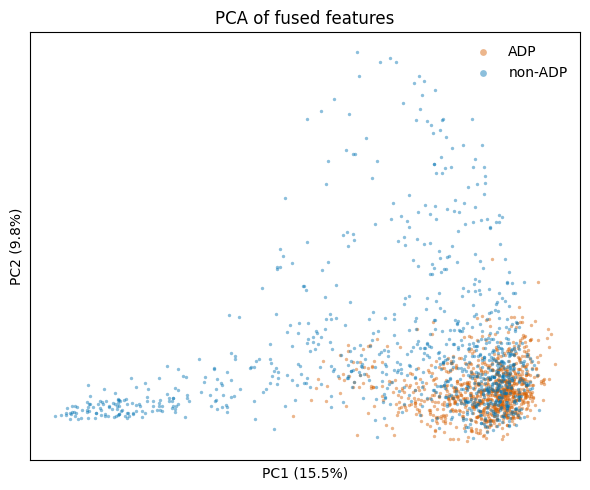

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xz) # reduce to 2 components for visualisation
emb_pca = pca.transform(Xz)
print(f"PC1 + PC2 explain {pca.explained_variance_ratio_[:2].sum():.1%} of variance")

# Plot the figure
fig, ax = plt.subplots(figsize=(6, 5))
scatter(ax, emb_pca, "PCA of fused features")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout(); plt.show()

**Interpreting the explained variance.** PCA projects the 1287-d fused vectors onto their directions of greatest spread; PC1 + PC2 are the two largest. Together they explain **25.3%** of the total variance (PC1 = 15.5%, PC2 = 9.8%), so this 2-D plot captures only about a quarter of the structure — the remaining ~75% lies in dimensions not shown. This is normal for high-dimensional PLM embeddings, where signal is spread across many axes.

Im treating the plot as a compressed sanity check, not proof of separability. Classes that overlap here may still be well separated in the full 1287-d space the classifiers actually use.

## 3. UMAP

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


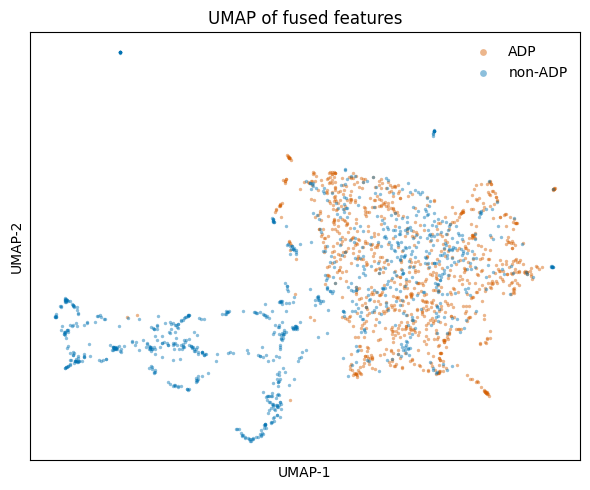

In [ ]:
# use umap to reduce the fused features to 2D for visualisation
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
emb_umap = reducer.fit_transform(Xz)

# Plot the figure
fig, ax = plt.subplots(figsize=(6, 5))
scatter(ax, emb_umap, "UMAP of fused features")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

## 4. Quantitative separation

Silhouette score by class on each 2-D projection: ranges from -1 (classes fully intermingled) through 0 (overlapping) to 1 (cleanly separated). For a frozen-feature space on short peptides, I expect a low-but-positive value representing a present structure, but far from a clean separation.

In [5]:
for name, emb in [("PCA", emb_pca), ("UMAP", emb_umap)]:
    print(f"{name:5} silhouette (by class): {silhouette_score(emb, y):.3f}")

PCA   silhouette (by class): 0.145
UMAP  silhouette (by class): 0.164


Projecting the fused feature vector with PCA and UMAP reveals partial rather than clean separation between ADPs and non-ADPs. The first two principal components capture 25% of the variance, at 15.5% and 9.8% respectively. Both projections show the same structure. A subset of non-ADPs forms a distinct elongated branch that is well separated from the ADP population, indicating that part of the negative class is readily distinguishable in the learned space. This branch most plausibly reflects the hard negatives, whose generic protein composition differs markedly from that of bioactive peptides. The remaining non-ADPs intermingle extensively with ADPs in a dense central region that constitutes the demanding decision boundary the dual-negative design was constructed to create. Silhouette scores of 0.15 for PCA and 0.16 for UMAP quantify this picture, confirming that class-relevant structure is present without the classes being cleanly resolved. The visualisation therefore indicates that the frozen fused representation encodes genuine discriminative signal yet cannot by itself separate ADPs from the bioactive negatives, which supports the decision to pursue task-specific fine-tuning rather than rely on frozen embeddings.